## Question

> **How do snowfall and snowpack depth affect solar energy production?**

Active snowfall is likely to cause a decreased in solar energy production. This could be via a combination of accumulated snow physically blocking the panel and increased cloud cover reducing sunlight. Potentially, persistent snowpack (snow has high albedo) could increase solar production by reflecting sunlight onto the panel.

### Imports:

In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Data Cleaning:

#### Load raw data

In [2]:
# import the data
precipitation = pd.read_csv("Data/precipitation.csv")
solar = pd.read_csv("Data/solar.csv")
sun = pd.read_csv("Data/sun.csv")
weather = pd.read_csv("Data/weather.csv")

In [3]:
precipitation.head()

,Date,Precip in.,24-hr Snowfall in.,Snowpack Depth in.
0,1/1/2017,0.01,0.2,4
1,1/2/2017,0,0,4
2,1/3/2017,T,T,3
3,1/4/2017,0.2,0.5,3
4,1/5/2017,0.02,0.2,2.5


In [4]:
solar.head()

,date,value
0,7/27/2017 0:00,NaN
1,7/27/2017 0:15,NaN
2,7/27/2017 0:30,NaN
3,7/27/2017 0:45,NaN
4,7/27/2017 1:00,NaN


In [5]:
sun.head()

,date,sunrise,sunset,elevation,azimuth
0,2017-01-01,07:28:34,16:22:27,22.506600,181.117426
1,2017-01-02,07:28:35,16:23:23,22.599328,181.003083
2,2017-01-03,07:28:32,16:24:20,22.699437,180.890026
3,2017-01-04,07:28:28,16:25:19,22.806883,180.778345
4,2017-01-05,07:28:20,16:26:20,22.921620,180.668129


In [6]:
weather.head()

,date,temperatureMax,temperatureMin,rainTotal,rainPercent,barometerMax,barometerMin,cloudMax,cloudMin,humidityMax,humidityMin
0,2017-01-01,34.076,29.120,0.000,0.00,30.165,29.499,NaN,NaN,87.0,64.655
1,2017-01-02,40.764,14.106,0.026,0.35,30.314,30.165,NaN,NaN,85.0,79.000
2,2017-01-03,38.420,18.680,0.026,0.35,30.300,29.512,NaN,NaN,86.0,72.000
3,2017-01-04,38.219,31.376,0.259,3.47,29.512,29.118,NaN,NaN,86.0,74.000
4,2017-01-05,31.280,20.480,0.000,0.00,29.547,29.242,NaN,NaN,74.0,52.000


#### Standardize date columns

In [7]:
# making precipitation's "Date" lowercase to match all datasets
precipitation.rename(columns={"Date": "date"}, inplace=True)

# convert all date cols to datetime objects
weather['date'] = pd.to_datetime(weather['date'])
precipitation['date'] = pd.to_datetime(precipitation['date'])
sun['date'] = pd.to_datetime(sun['date'])
solar['date'] = pd.to_datetime(solar['date']).dt.normalize()

#### Aggregate solar to daily totals

Precipatation, weather, and sun are all measured daily, but solar is measured every 15 minutes. To align solar's granularity with the other data, we sum all readings within each day.

In [8]:
solar_daily = (
    solar
    .groupby('date', as_index=False)['value']
    .sum()
    .rename(columns={'value': 'daily_total'})
)

solar_daily.head()

,date,daily_total
0,2017-07-27,9089.0
1,2017-07-28,29376.0
2,2017-07-29,28863.0
3,2017-07-30,30777.0
4,2017-07-31,24836.0


#### Merge

In [9]:
solar_power = (
    solar_daily
    .merge(weather, on='date', how='inner')
    .merge(precipitation, on='date', how='inner')
    .merge(sun, on='date', how='inner')
)

In [10]:
solar_power.info()
solar_power.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                2182 non-null   datetime64[ns]
 1   daily_total         2182 non-null   float64       
 2   temperatureMax      2169 non-null   float64       
 3   temperatureMin      2169 non-null   float64       
 4   rainTotal           2182 non-null   float64       
 5   rainPercent         2182 non-null   float64       
 6   barometerMax        2182 non-null   float64       
 7   barometerMin        2182 non-null   float64       
 8   cloudMax            1014 non-null   float64       
 9   cloudMin            1014 non-null   float64       
 10  humidityMax         2169 non-null   float64       
 11  humidityMin         2169 non-null   float64       
 12  Precip in.          2182 non-null   object        
 13  24-hr Snowfall in.  2170 non-null   object      

,date,daily_total,temperatureMax,temperatureMin,rainTotal,rainPercent,barometerMax,barometerMin,cloudMax,cloudMin,humidityMax,humidityMin,elevation,azimuth
count,2182,2182.000000,2169.000000,2169.000000,2182.000000,2182.000000,2182.000000,2182.000000,1014.000000,1014.000000,2169.000000,2169.000000,2182.000000,2182.000000
mean,2020-07-30 16:21:20.293308928,13196.883593,59.447820,34.974488,0.096114,1.053529,30.066015,29.831957,4587.104190,2182.444886,78.446185,55.122409,44.672112,165.432903
min,2017-07-27 00:00:00,0.000000,-6.880000,-31.360000,0.000000,0.000000,29.288000,28.707000,1382.940000,1259.605000,41.000000,12.000000,21.977363,147.489358
25%,2019-01-23 06:00:00,2925.750000,40.016000,22.460000,0.000000,0.000000,29.938000,29.674500,3045.439000,1860.526250,76.000000,45.300000,29.268421,154.375207
50%,2020-08-04 12:00:00,12220.500000,61.250000,35.462000,0.000000,0.000000,30.080000,29.862000,4348.048000,2067.301000,80.000000,55.000000,44.999839,161.139763
75%,2022-01-31 18:00:00,22793.500000,79.544000,51.260000,0.056000,0.690000,30.207750,30.021000,5649.056750,2390.161500,83.000000,66.000000,60.093274,178.850418
max,2023-07-31 00:00:00,34084.000000,102.380000,72.140000,2.361000,27.080000,30.645000,30.432000,13250.730000,5834.939000,92.000000,89.000000,66.233336,186.908141
std,NaN,10390.188732,22.214269,20.120938,0.237238,2.554005,0.205972,0.263351,2001.566212,542.689624,7.291388,14.584514,15.510384,12.972975


In [11]:
# need to convert snow-related cols to numeric
cols_to_convert = ['Precip in.', '24-hr Snowfall in.', 'Snowpack Depth in.']

for col in cols_to_convert:
    # replace 'T' (likely representing a trace amount) with 0.001 in.
    solar_power['24-hr Snowfall in.'] = solar_power['24-hr Snowfall in.'].replace('T', 0.001)
    # convert to numeric (set non-convertables to NaN)
    solar_power[col] = pd.to_numeric(solar_power[col], errors='coerce')
    
solar_power.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                2182 non-null   datetime64[ns]
 1   daily_total         2182 non-null   float64       
 2   temperatureMax      2169 non-null   float64       
 3   temperatureMin      2169 non-null   float64       
 4   rainTotal           2182 non-null   float64       
 5   rainPercent         2182 non-null   float64       
 6   barometerMax        2182 non-null   float64       
 7   barometerMin        2182 non-null   float64       
 8   cloudMax            1014 non-null   float64       
 9   cloudMin            1014 non-null   float64       
 10  humidityMax         2169 non-null   float64       
 11  humidityMin         2169 non-null   float64       
 12  Precip in.          1942 non-null   float64       
 13  24-hr Snowfall in.  2167 non-null   float64     

Let's create a new dataframe (`snow_solar`) with precipitation and solar production data, only keeping rows with non-missing values for all three snow variables *and* solar production).

In [12]:
snow_solar = (
    solar_power[['date', 'daily_total', '24-hr Snowfall in.', 'Snowpack Depth in.']]
    # rename cols from precip to be shorter
    .rename(
        columns={
            '24-hr Snowfall in.': 'snowfall',
            'Snowpack Depth in.': 'snowpack',
        }
    )
    # drop rows w/ NaN in all target numeric cols 
    .dropna(subset=['snowfall', 'snowpack', 'daily_total'])
)

snow_solar.head()

,date,daily_total,snowfall,snowpack
0,2017-07-27,9089.0,0.0,0.0
1,2017-07-28,29376.0,0.0,0.0
2,2017-07-29,28863.0,0.0,0.0
3,2017-07-30,30777.0,0.0,0.0
8,2017-08-04,24422.0,0.0,0.0


In [13]:
print(f'There are {snow_solar.query('daily_total == 0').shape[0]} days with 0 reported solar generation')

There are 84 days with 0 reported solar generation


Days with no solar generation may be due to an offline sensor, but also could be the result of snow temporarily blocking the panel. Let's keep days with no solar generation, and reference `weather`/`sun` when tackling our final question(s).

In [14]:
# # drop days where solar reported 0 (likely offline sensor or similar)
# snow_solar = snow_solar[snow_solar['daily_total'] > 0].reset_index(drop=True)

# snow_solar['daily_total'].min() != 0

### EDA:
#### Summary statistics

In [15]:
snow_solar[['daily_total', 'snowfall', 'snowpack']].describe()

,daily_total,snowfall,snowpack
count,2000.000000,2000.000000,2000.000000
mean,13115.067000,0.375419,2.699100
std,10434.663859,1.256951,5.001467
min,0.000000,0.000000,0.000000
25%,2633.750000,0.000000,0.000000
50%,12291.500000,0.000000,0.000000
75%,22784.500000,0.001000,3.500000
max,34084.000000,14.300000,27.000000


Let's identify months with any snowfall to get informative summary stats for snow variables.

In [16]:
# find months with non-0 snowpack
snow_months = snow_solar[snow_solar['snowpack'] > 0]['date'].dt.month.unique()

In [17]:
# summary stats for months w/ persistent snowpack
snow_solar[snow_solar['date'].dt.month.isin(snow_months)].describe()

,date,daily_total,snowfall,snowpack
count,1297,1297.000000,1297.000000,1297.000000
mean,2020-07-26 06:56:20.724749312,9536.626831,0.578904,4.162066
min,2017-10-01 00:00:00,0.000000,0.000000,0.000000
25%,2019-01-27 00:00:00,877.000000,0.000000,0.000000
50%,2020-05-31 00:00:00,5432.000000,0.000000,1.000000
75%,2022-01-25 00:00:00,17028.000000,0.300000,7.000000
max,2023-05-31 00:00:00,34084.000000,14.300000,27.000000
std,NaN,10030.269799,1.522842,5.699994


In [18]:
# summary stats for months w/o persistent snowpack
snow_solar[~snow_solar['date'].dt.month.isin(snow_months)].describe()

,date,daily_total,snowfall,snowpack
count,703,703.000000,703.000000,703.0
mean,2020-08-04 04:18:05.633001472,19717.110953,0.000001,0.0
min,2017-07-27 00:00:00,705.000000,0.000000,0.0
25%,2019-06-03 12:00:00,14227.000000,0.000000,0.0
50%,2020-08-02 00:00:00,21503.000000,0.000000,0.0
75%,2021-09-29 12:00:00,26083.000000,0.000000,0.0
max,2023-07-31 00:00:00,31976.000000,0.001000,0.0
std,NaN,7550.373875,0.000038,0.0


Let's make a new df for months where snowfall is possible so we can more cleanly visualize the relationship between snowfall/snowpack depth on solar production. 

In [19]:
snow_solar_analysis = snow_solar[snow_solar['date'].dt.month.isin(snow_months)].copy()

In [20]:
snow_solar_analysis.head()

,date,daily_total,snowfall,snowpack
66,2017-10-01,26868.0,0.0,0.0
67,2017-10-02,26184.0,0.0,0.0
68,2017-10-03,26112.0,0.0,0.0
69,2017-10-04,23440.0,0.0,0.0
70,2017-10-05,18981.0,0.0,0.0


#### Distribution of daily solar production

*Note: Referenced Plotly documentation to format axes/layout, add LOWESS trendline, etc.*

> URLs:
> - https://plotly.com/python/reference/layout/xaxis/
> - https://plotly.com/python/reference/layout/yaxis/
> - https://plotly.com/python/reference/layout/
> - https://plotly.com/python/linear-fits/*

In [21]:
# create dictionary to add outline around histograms
hist_outline = {
    'line': {
        'color': 'black',
        'width': 1
    }
}

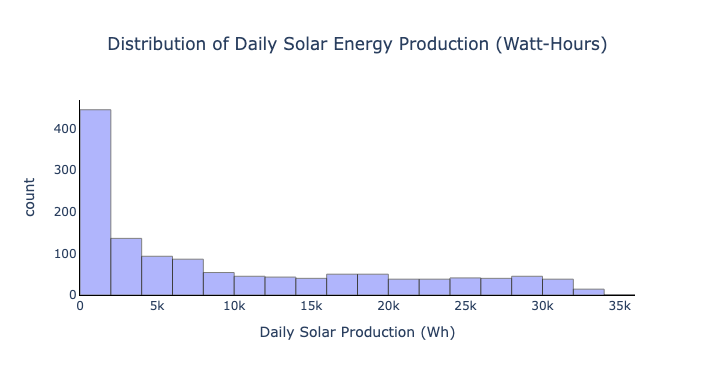

In [22]:
# make histogram
solar_hist = px.histogram(
    snow_solar_analysis,
    x='daily_total',
    barmode='overlay',
    title='Distribution of Daily Solar Energy Production (Watt-Hours)',
    labels={'daily_total': 'Daily Solar Production (Wh)'}
).update_traces(
    marker=hist_outline # add outline around bins
).update_xaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

solar_hist.show()

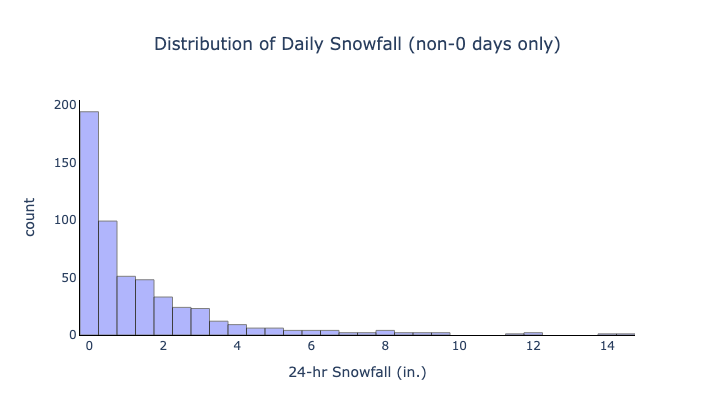

In [23]:
# distribution of snowfall (non-0 days only to evaluate shape during periods w/ active snowfall)
snowfall_hist = px.histogram(
    snow_solar_analysis[snow_solar_analysis['snowfall'] > 0],
    x='snowfall',
    barmode='overlay',
    height=400,
    title='Distribution of Daily Snowfall (non-0 days only)',
    labels={'snowfall': '24-hr Snowfall (in.)'}
).update_traces(
    marker=hist_outline # add outline around bins
).update_xaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

snowfall_hist.show()

#### Snow vs. No-Snow days

A logical comparison to make is whether days with any measurable recorded snowfall produce less solar energy than days without.

In [24]:
# create dummy variable `snow_day` for whether any measurable snowfall
snow_solar_analysis['snow_day'] = np.where(
    snow_solar_analysis['snowfall'] > 0,
    'Snow day',
    'No snow'
)

In [25]:
# look at counts
snow_solar_analysis['snow_day'].value_counts()

snow_day
No snow     761
Snow day    536
Name: count, dtype: int64

Out of 1297 total days with valid data during months w/ persistent snowpack, 536 had recorded snowfall and 761 did not!

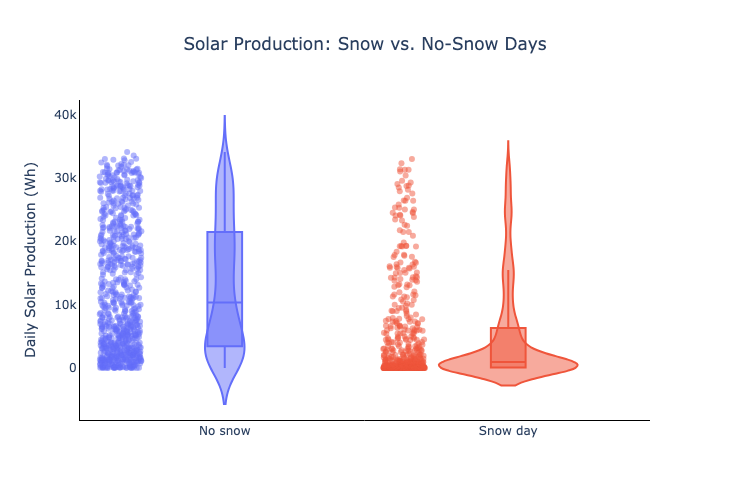

In [26]:
# make violin plot to visualize (data is high density)
solar_by_snowday = px.violin(
    snow_solar_analysis,
    x='snow_day',
    y='daily_total',
    color='snow_day',
    box=True,
    points='all',
    height=500,
    title='Solar Production: Snow vs. No-Snow Days',
    labels={
        'daily_total': 'Daily Solar Production (Wh)',
        'snow_day': ''
    }
).update_traces(
    marker_opacity=0.5
).update_xaxes(
    showline=True,
    linewidth=1,
    linecolor='black',
).update_yaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)',
    # hide legend (b/c redundant)
    showlegend=False
)

solar_by_snowday.show()

In [27]:
# calculate summary stats for both groups
(
    snow_solar_analysis
    .groupby('snow_day')
    .daily_total
    .describe()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
snow_day,,,,,,,,
No snow,761.0,12792.01,10155.42,0.0,3408.0,10337.0,21444.0,34084.0
Snow day,536.0,4914.72,7792.91,0.0,50.0,915.0,6285.0,33005.0


There is a substantial difference in production between snow (median: ~915 Wh) and non-snow days (median: ~10337 Wh). Violin plot reveals a spike in 0/near-0 solar production days for snow days, but there's more overlap at higher production values.

#### Scatterplots - Snowfall & Snowpack vs. Solar production

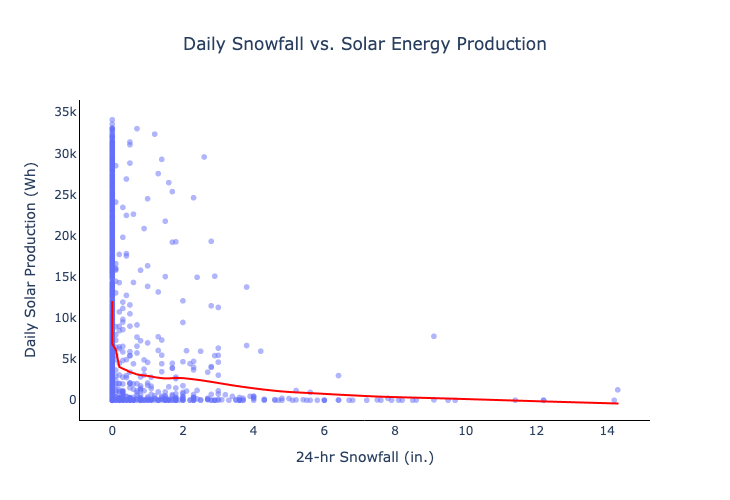

In [28]:
snowfall_vs_solar = px.scatter(
    snow_solar_analysis,
    x='snowfall',
    y='daily_total',
    opacity=.5,
    # use LOWESS for trendline (outlier at 24-hr snowfall of ~14.3 in. causes OLS line to go negative)
    trendline='lowess',
    trendline_color_override='red',
    height=500,
    title='Daily Snowfall vs. Solar Energy Production',
    labels={
        'snowfall': '24-hr Snowfall (in.)',
        'daily_total': 'Daily Solar Production (Wh)'
    }
).update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

snowfall_vs_solar.show()

In [29]:
print(f"There are {snow_solar_analysis.query('snow_day == "No snow"').shape[0]} days with 0 inches of recorded 24-hr snowfall.")

There are 761 days with 0 inches of recorded 24-hr snowfall.


Let's make another scatterplot, but without 'No snow' (as to better understand the relationship between snowfall and solar production).

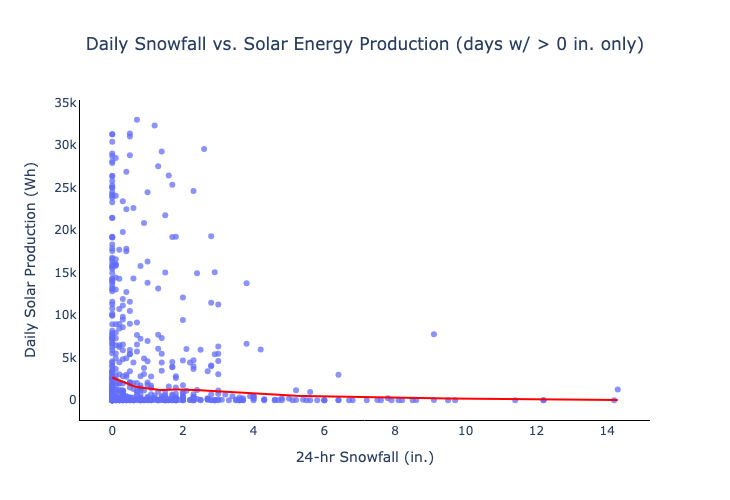

In [30]:
snowfall_vs_solar_filter = px.scatter(
    snow_solar_analysis.query('snow_day == "Snow day"'),
    x='snowfall',
    y='daily_total',
    opacity=0.75,
    trendline='lowess',
    trendline_color_override='red',
    height=500,
    title='Daily Snowfall vs. Solar Energy Production (days w/ > 0 in. only)',
    labels={
        'snowfall': '24-hr Snowfall (in.)',
        'daily_total': 'Daily Solar Production (Wh)'
    }
).update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

snowfall_vs_solar_filter.show()

Both scatterplots for daily snowfall show a sharp decline in solar production as 24-hr Snowfall increases, which could be caused by a combination of cloud cover (to be investigated later!) and snow blocking the panel.

Looking at snowpack next...

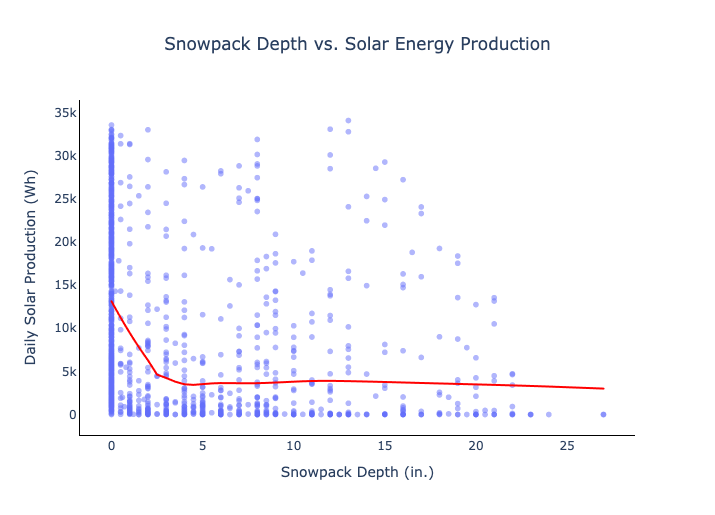

In [31]:
snowpack_vs_solar = px.scatter(
    snow_solar_analysis,
    x='snowpack',
    y='daily_total',
    opacity=.5,
    # use LOWESS again
    trendline='lowess',
    trendline_color_override='red',
    height=500,
    title='Snowpack Depth vs. Solar Energy Production',
    labels={
        'snowpack': 'Snowpack Depth (in.)',
        'daily_total': 'Daily Solar Production (Wh)'
    }
).update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

snowpack_vs_solar.show()

In [32]:
print(f"There are {snow_solar_analysis.query('snowpack == 0').shape[0]} days with a snowpack of 0 inches!")

There are 599 days with a snowpack of 0 inches!


Similarly to what we did with snowfall, let's make another scatterplot, this time excluding days with no snowpack (as to better understand the relationship between persistent snowpack and solar production).

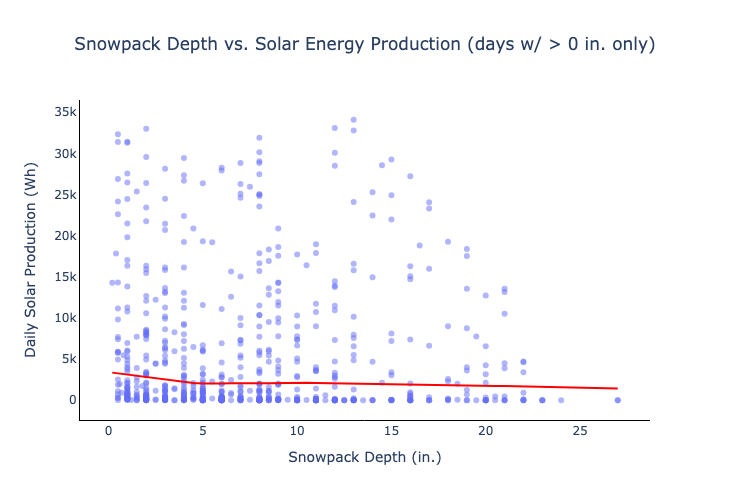

In [33]:
snowpack_vs_solar_filter = px.scatter(
    snow_solar.query('snowpack > 0'),
    x='snowpack',
    y='daily_total',
    opacity=0.5,
    trendline='lowess',
    trendline_color_override='red',
    height=500,
    title='Snowpack Depth vs. Solar Energy Production (days w/ > 0 in. only)',
    labels={
        'snowpack': 'Snowpack Depth (in.)',
        'daily_total': 'Daily Solar Production (Wh)'
    }
).update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

snowpack_vs_solar_filter.show()

The relatively flat (if not descending) LOWESS line for solar production for days with > 0 in. snowpack depth suggests that our hypothesis that reflected light could increase solar production is incorrect.

#### Correlation matrix

Before starting to build a model, we check correlation strength between each snow variable and solar production, as well as between snow variables (check for multicollinearity, etc.).

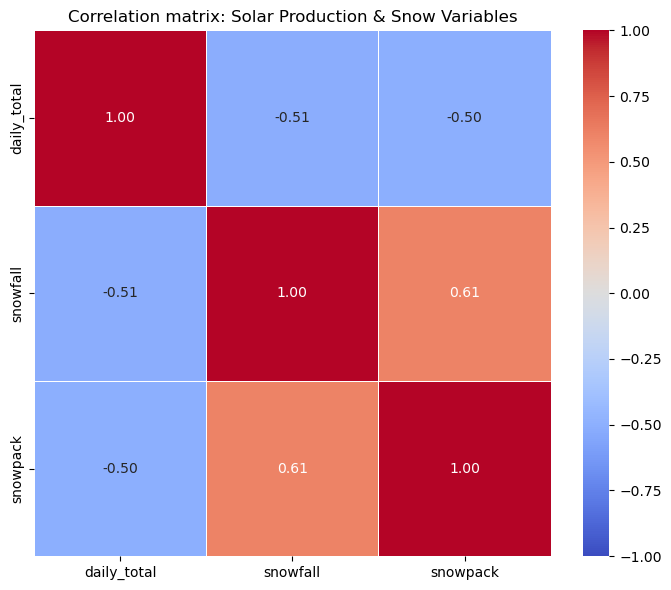

In [34]:
# make heatmap
plt.figure(figsize=(7,6))

sns.heatmap(
    snow_solar_analysis[['daily_total', 'snowfall', 'snowpack']].corr(method='spearman'),
    cmap='coolwarm',
    vmax=1,
    vmin=-1,
    annot=True,
    fmt='.2f',
    linewidth=0.5
)

plt.title('Correlation matrix: Solar Production & Snow Variables')

plt.tight_layout()
plt.show()

Both snow variables have moderate/strong negative correlations with solar production. Additionally, they are moderately correlated with one another, indicating some multicollinearity (i.e., days with new snowfall tend to have more snowpack, vice-versa), but not strong to the extent that a regression model would be destablized. This suggests LASSO is likely to prefer one predictor over the other when penalized.

*Note: Moderate/strong negative correlation between snowpack and solar production indicates data doesn't support hypothesis that snowpack increases production via reflected light.*

### Machine Learning

#### Method #1: MLR
Goal -> Estimate the effect of snowfall and snowpack on daily solar energy production (inference)

Let's keep using the `snow_solar_analysis` df so that we're investigating how the presence of snow (persistent or fresh) impacts solar production as compared to a winter day without snow.

In [35]:
# grab features...
X_snow = snow_solar_analysis[['snowfall', 'snowpack']]
# ...and target
y_snow = snow_solar_analysis['daily_total']

# do 80/20 train/test split for both (w/ class seed for reproducibility)
X_train_snow, X_test_snow, y_train_snow, y_test_snow = train_test_split(X_snow, y_snow, test_size=.2, shuffle=True, random_state=3870)

In [36]:
# start the 'engine'
snow_solar_mlr = LinearRegression()

# fit the model
snow_solar_mlr.fit(
    X=X_train_snow,
    y=y_train_snow
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
# evaluate - coefficients
snow_solar_mlr_coeff = pd.DataFrame({
    'feature': X_snow.columns,
    'estimate': snow_solar_mlr.coef_
})

snow_solar_mlr_coeff

,feature,estimate
0,snowfall,-1064.885693
1,snowpack,-439.512222


In [38]:
# evaluate - R2
r2_train = round(snow_solar_mlr.score(X_train_snow, y_train_snow), 3)
r2_test = round(snow_solar_mlr.score(X_test_snow, y_test_snow), 3)

print(f"R2 (train): {r2_train}")
print(f"R2 (test): {r2_test}")

R2 (train): 0.125
R2 (test): 0.136


Both coefficients are negative as expected; more snowfall and deeper snowpack both predict less solar production.

The R2 (13.6%) is about what should be expected given the moderate/strong correlations we saw earlier, and supports the idea that while the snow variables are relevant predictors, a large portion of variation in solar production is driven by other factors not included in the model.

The minimal difference between train/test R2 indicates the model generalizes well (low variance), but the low R2 values indicate it's bias-heavy on the bias/variance trade-off spectrum.

Let's take a look at the residuals...

In [39]:
# calculate residuals
y_hat_snow = snow_solar_mlr.predict(X=X_test_snow)
res_snow = y_test_snow.values - y_hat_snow

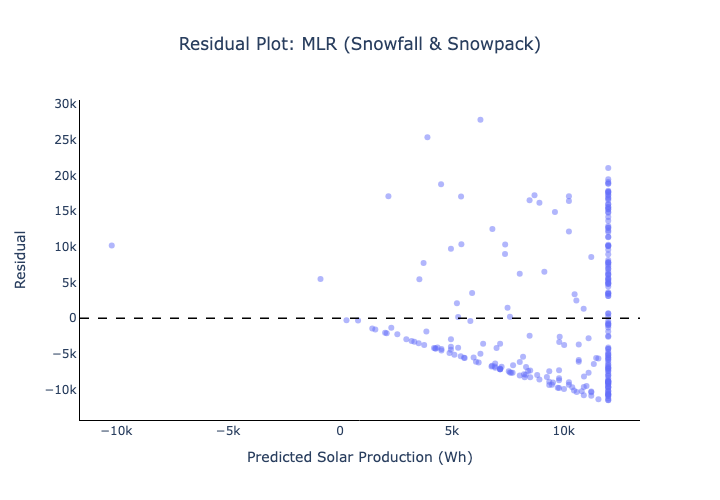

In [40]:
# make residual plot to check mlr assumptions & conditions
snow_solar_mlr_res = px.scatter(
    x=y_hat_snow,
    y=res_snow,
    opacity=0.5,
    height=500,
    labels={
        'x': 'Predicted Solar Production (Wh)',
        'y': 'Residual'
    },
    title='Residual Plot: MLR (Snowfall & Snowpack)'
).add_hline(
    y=0,
    line_width=1.5,
    line_color='black',
    line_dash='dash'
).update_xaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

snow_solar_mlr_res.show()

 The clear hetereoskedasticity in the residual plot makes sense given the high density of low production on snowdays and the wide spread on non-snow days earlier observed. As snow variables are the only predictors, the model predicts ~12k Wh for any non-snow day (resulting in the dense stack of points at ~12k Wh), while actual production varies widly from factors not included in the model.

 The hetereoskedasticity (errors growing larger at higher predicted production values) supports the notion that while snow variables *do* negatively impact solar production, they're insufficient alone to explain the variance on days with high-production. Adding additional atmospheric predictors (e.g., cloud cover) and utilizing LASSO regularization will be necesary to address the unmodeled variance.

# Q's 4/5 Prep:

*Which weather variable has the strongest relationship with solar energy production?*

{EDA reveals weather variables all impact solar production...}. However, as these variables are often highly correlated, they cannot be effectively evaluated individually / in isolation. Further, the MLR model for the impact of snow variables on solar production shows significant heteroskedasticity, indicating a simple linear model doesn't effectively capture the relationship between weather variables and solar production. To identify a single strongest predictor, let's use LASSO + OLS to isolate linear effects, a Random Forest to capture non-linear effects, and compare the results of both methods.

LASSO Rationale:
* Adding more predictors to try to address heteroskedasticity (explain more variance!)
* Doing so increases risk of multicollinearity + overfitting (high model variance)
* Use LASSO to identify/remove redundant weather variables  

In [41]:
solar_power.describe()

,date,daily_total,temperatureMax,temperatureMin,rainTotal,rainPercent,barometerMax,barometerMin,cloudMax,cloudMin,humidityMax,humidityMin,Precip in.,24-hr Snowfall in.,Snowpack Depth in.,elevation,azimuth
count,2182,2182.000000,2169.000000,2169.000000,2182.000000,2182.000000,2182.000000,2182.000000,1014.000000,1014.000000,2169.000000,2169.000000,1942.000000,2167.000000,2000.000000,2182.000000,2182.000000
mean,2020-07-30 16:21:20.293308928,13196.883593,59.447820,34.974488,0.096114,1.053529,30.066015,29.831957,4587.104190,2182.444886,78.446185,55.122409,0.148244,0.350798,2.699100,44.672112,165.432903
min,2017-07-27 00:00:00,0.000000,-6.880000,-31.360000,0.000000,0.000000,29.288000,28.707000,1382.940000,1259.605000,41.000000,12.000000,0.000000,0.000000,0.000000,21.977363,147.489358
25%,2019-01-23 06:00:00,2925.750000,40.016000,22.460000,0.000000,0.000000,29.938000,29.674500,3045.439000,1860.526250,76.000000,45.300000,0.000000,0.000000,0.000000,29.268421,154.375207
50%,2020-08-04 12:00:00,12220.500000,61.250000,35.462000,0.000000,0.000000,30.080000,29.862000,4348.048000,2067.301000,80.000000,55.000000,0.020000,0.000000,0.000000,44.999839,161.139763
75%,2022-01-31 18:00:00,22793.500000,79.544000,51.260000,0.056000,0.690000,30.207750,30.021000,5649.056750,2390.161500,83.000000,66.000000,0.160000,0.001000,3.500000,60.093274,178.850418
max,2023-07-31 00:00:00,34084.000000,102.380000,72.140000,2.361000,27.080000,30.645000,30.432000,13250.730000,5834.939000,92.000000,89.000000,3.680000,14.300000,27.000000,66.233336,186.908141
std,NaN,10390.188732,22.214269,20.120938,0.237238,2.554005,0.205972,0.263351,2001.566212,542.689624,7.291388,14.584514,0.300759,1.211737,5.001467,15.510384,12.972975


### Train/Test Split

In [66]:
# ensure no NaNs in weather var columns
solar_power = solar_power.dropna(subset=['temperatureMax', 'temperatureMin', 'rainTotal', 'rainPercent', 'barometerMax', 'barometerMin', 'cloudMax', 'cloudMin', 'humidityMax', 'humidityMin', 'Precip in.', '24-hr Snowfall in.', 'Snowpack Depth in.'])

In [67]:
# grab features...
X_strongest = solar_power[['temperatureMax', 'temperatureMin', 'rainTotal', 'rainPercent', 'barometerMax', 'barometerMin', 'cloudMax', 'cloudMin', 'humidityMax', 'humidityMin', 'Precip in.', '24-hr Snowfall in.', 'Snowpack Depth in.']]
# ...and target
y_strongest = solar_power['daily_total']

# do 80/20 train/test split for both (w/ class seed for reproducibility)
X_train_strongest, X_test_strongest, y_train_strongest, y_test_strongest = train_test_split(X_strongest, y_strongest, test_size=.2, shuffle=True, random_state=3870)

### Standardization

Weather variables are in varying units, so comparing coefficients estimated from their 'as-is' values wouldn't be informative/helpful. To resolve this and enable comparison of effect size, let's standardize the weather variables:

In [68]:
from sklearn.preprocessing import StandardScaler

# start engine
scaler = StandardScaler()

# fit scaler for X_train_strongest's mean/sd
scaler.fit(X_train_strongest)

# make scaled train df
X_train_strongest_scaled = (
    pd.DataFrame(
        scaler.transform(X_train_strongest),
        columns = X_train_strongest.columns
    )
)

# verify via mean / sd
pd.DataFrame({
    'mean': np.mean(X_train_strongest_scaled).round(5),
    'sd': np.std(X_train_strongest_scaled)
})

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning:

The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



,mean,sd
temperatureMax,-0.0,1.0
temperatureMin,-0.0,1.0
rainTotal,-0.0,1.0
rainPercent,-0.0,1.0
barometerMax,-0.0,1.0
barometerMin,-0.0,1.0
cloudMax,-0.0,1.0
cloudMin,-0.0,1.0
humidityMax,-0.0,1.0
humidityMin,-0.0,1.0


In [69]:
# make scaled test df
X_test_strongest_scaled = (
    pd.DataFrame(
        scaler.transform(X_test_strongest),
        columns = X_test_strongest.columns
    )
)

# check mean / sd
pd.DataFrame({
    'mean': np.mean(X_test_strongest_scaled).round(5),
    'sd': np.std(X_test_strongest_scaled)
})

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning:

The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)



,mean,sd
temperatureMax,-0.00712,0.989336
temperatureMin,-0.00712,0.937865
rainTotal,-0.00712,0.903688
rainPercent,-0.00712,1.024483
barometerMax,-0.00712,0.923328
barometerMin,-0.00712,0.907210
cloudMax,-0.00712,0.920492
cloudMin,-0.00712,0.914795
humidityMax,-0.00712,0.913460
humidityMin,-0.00712,0.962494


### LASSO Reg w/ CV

In [70]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold

#### Find Optimal Lambda

As LASSO uses penalization to 'push' less-important variables to 0, let's do K-Fold CV (via `LassoCV`) to find the optimal value of lambda (avoid overfitting):

(Use LassoCV w/ train set of scaled predictors to identify optimal lambda via K-Fold CV )

In [71]:
# setup folds
cv_folds = RepeatedKFold(
    n_splits = 10,
    n_repeats = 10,
    random_state = 3870
)

In [80]:
# FIX ERROR --> NaN's in X_train_strongest_scaled
lasso_search_strongest = (
    LassoCV(
        alphas = np.arange(.01, 50, .01),
        cv = cv_folds,
        n_jobs = -1 # all cores!
    )
    .fit(
        X = X_train_strongest_scaled,
        y = y_train_strongest
    )
)

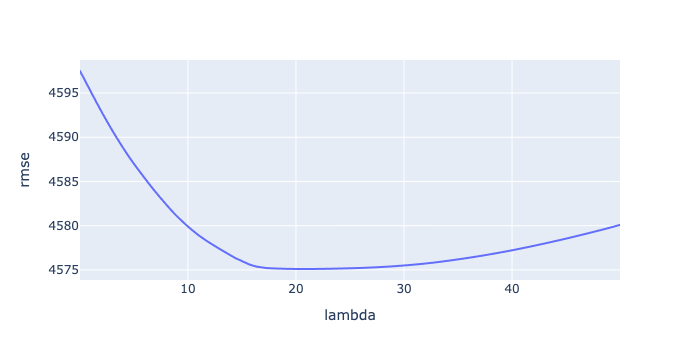

In [81]:
# visualize results:
lasso_search_strongest_viz = px.line(
    pd.DataFrame({
        'lambda': lasso_search_strongest.alphas,
        # flip rmse order
        'rmse': np.flip(np.sqrt(lasso_search_strongest.mse_path_.mean(axis=1)))
    }),
    x = 'lambda',
    y = 'rmse'
)

lasso_search_strongest_viz

In [82]:
# best choice of lambda is...
print(f'Best choice of lambda is {lasso_search_strongest.alpha_}')

Best choice of lambda is 20.7


In [83]:
# check out results
lasso_strongest_results = (
    pd.DataFrame({
    'weather variable (feature)': X_train_strongest_scaled.columns,
    'estimate': lasso_search_strongest.coef_.round(2)
    })
    # filter out features w/ slopes of 0
    .query('estimate != 0')
)

lasso_strongest_results

,weather variable (feature),estimate
0,temperatureMax,5828.51
1,temperatureMin,-1715.97
2,rainTotal,-316.74
3,rainPercent,-798.85
4,barometerMax,-510.82
5,barometerMin,1390.19
6,cloudMax,1077.72
7,cloudMin,-2480.55
9,humidityMin,-4777.51
10,Precip in.,932.39


(humidityMax is the only feature removed)

In [88]:
remaining_features = ['temperatureMax', 'temperatureMin', 'rainTotal', 'rainPercent', 'barometerMax', 'barometerMin', 'cloudMax', 'cloudMin', 'humidityMin', 'Precip in.', '24-hr Snowfall in.', 'Snowpack Depth in.']

### OLS
Use these features in an OLS model to understand effect size w/o penalization   

In [97]:
strongest_mlr = (
    LinearRegression()
    # fit with train set
    .fit(
        X = X_train_strongest_scaled[remaining_features],
        y = y_train_strongest
    )
)

In [98]:
# evaluate - coefficients
strongest_mlr_coeff = pd.DataFrame({
    'feature': X_train_strongest_scaled[remaining_features].columns,
    'estimate': strongest_mlr.coef_
})

strongest_mlr_coeff

,feature,estimate
0,temperatureMax,6067.496725
1,temperatureMin,-1949.809603
2,rainTotal,-357.690953
3,rainPercent,-775.442536
4,barometerMax,-617.305342
5,barometerMin,1479.832106
6,cloudMax,976.061825
7,cloudMin,-2523.217349
8,humidityMin,-4842.731650
9,Precip in.,977.264431


Strongest Weather Variables:
* `temperatureMax`
* `humidityMin`
* `cloudMin`

In terms of linear relationships, sunny (low `cloudMin`), dry (low `humidityMin`), and hot (high `temperatureMax`) days produce the strongest solar production.

In [101]:
# evaluate - R2
r2_train_strongest = round(strongest_mlr.score(X_train_strongest_scaled[remaining_features], y_train_strongest), 3)
r2_test_strongest = round(strongest_mlr.score(X_test_strongest_scaled[remaining_features], y_test_strongest), 3)

print(f"R2 (train): {r2_train_strongest}")
print(f"R2 (test): {r2_train_strongest}")

R2 (train): 0.806
R2 (test): 0.806


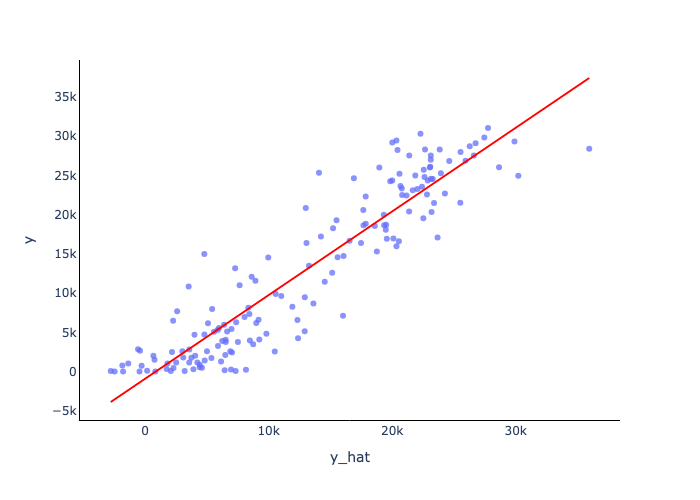

In [105]:
# visualize via R2 plot:
lasso_strongest_R2 = px.scatter(
    pd.DataFrame({
        'y': y_test_strongest,
        'y_hat': strongest_mlr.predict(
            X = X_test_strongest_scaled[remaining_features]
        )
    }),
    x='y_hat',
    y='y',
    opacity=0.75,
    trendline='ols',
    trendline_color_override='red',
    height=500,
    title=''
).update_xaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showgrid=False,
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

lasso_strongest_R2.show()

### Random Forests

* Use all weather variables (multicollinearity is okay!)

In [122]:
from sklearn.model_selection import KFold
# define dict for grid search 

hyper_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 400, 500],
    'max_features': np.arange(1, 11, 1).tolist(),
    'max_depth': [1, 2, 10, 20, 50, None]
}

# setup 5-fold cv partition
cv5 = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 3870
)

In [123]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn import tree, ensemble

# setup search
strongest_rand_search = RandomizedSearchCV(
    ensemble.RandomForestRegressor(random_state = 3870),
    param_distributions = hyper_grid,
    n_iter = 100,
    cv = cv5,
    random_state = 3870,
    n_jobs = -1
)

In [124]:
import time

# time search
start = time.time()

# train {x} models
strongest_rand_search.fit(X_train_strongest_scaled, y_train_strongest)

end = time.time()
print(f'Search time: {end-start: .3f} sec.')

Search time:  17.568 sec.


In [125]:
# evaluate
print(f'Best params: {strongest_rand_search.best_params_}')

Best params: {'n_estimators': 100, 'max_features': 4, 'max_depth': 10}


In [129]:
print(f'Forest from random search has an R2 of: {strongest_rand_search.best_estimator_.score(X_test_strongest_scaled, y_test_strongest): .3f}')

Forest from random search has an R2 of:  0.860


In [132]:
# feature_importances_

feat_imp_strongest = (
    pd.DataFrame({
        'feature': X_test_strongest_scaled.columns,
        'importance': strongest_rand_search.best_estimator_.feature_importances_
    })
    .sort_values(
        by = 'importance',
        ascending = False
    )
)

feat_imp_strongest

,feature,importance
6,cloudMax,0.307415
0,temperatureMax,0.223946
9,humidityMin,0.152675
12,Snowpack Depth in.,0.065843
1,temperatureMin,0.058163
7,cloudMin,0.036357
5,barometerMin,0.033067
8,humidityMax,0.028862
11,24-hr Snowfall in.,0.021399
3,rainPercent,0.020899


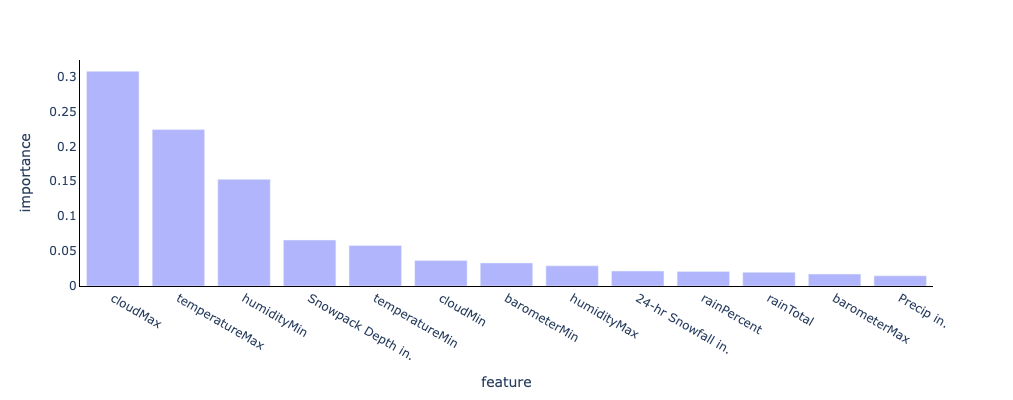

In [137]:
# visualize importance

rf_strongest_feat_imp = px.bar(
    feat_imp_strongest,
    x='feature',
    y='importance',
    barmode='overlay',
    height=400,
    title=''
).update_xaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_yaxes(
    showline=True,
    linewidth=1,
    linecolor='black'
).update_layout(
    title={'x': 0.5},
    plot_bgcolor='rgba(0,0,0,0)'
)

rf_strongest_feat_imp.show()

### Compare & Evaluate Results

*Can atmospheric and snow conditions predict whether a day will have high or low solar energy production?*

In [141]:
# (calculate OLS 'importance'?)
strongest_mlr_coeff['estimate_abs'] = strongest_mlr_coeff['estimate'].abs()

ols_total_effect = strongest_mlr_coeff['estimate_abs'].sum()

strongest_mlr_coeff['ols_importance'] = strongest_mlr_coeff['estimate_abs'] / ols_total_effect

strongest_mlr_coeff.sort_values(
    by='ols_importance',
    ascending = False
)

,feature,estimate,estimate_abs,ols_importance
0,temperatureMax,6067.496725,6067.496725,0.283660
8,humidityMin,-4842.731650,4842.731650,0.226402
7,cloudMin,-2523.217349,2523.217349,0.117962
1,temperatureMin,-1949.809603,1949.809603,0.091155
5,barometerMin,1479.832106,1479.832106,0.069183
9,Precip in.,977.264431,977.264431,0.045688
6,cloudMax,976.061825,976.061825,0.045632
3,rainPercent,-775.442536,775.442536,0.036253
4,barometerMax,-617.305342,617.305342,0.028860
10,24-hr Snowfall in.,-588.522859,588.522859,0.027514


In [146]:
ols_imp = strongest_mlr_coeff[['feature', 'ols_importance']]
rf_imp = feat_imp_strongest[['feature', 'importance']].rename(columns={'importance': 'rf_importance'})

ols_vs_rf = (
    pd.merge(
        ols_imp,
        rf_imp,
        on='feature'
    )
    .sort_values(
        by='rf_importance',
        ascending=False
    )
)

ols_vs_rf

,feature,ols_importance,rf_importance
6,cloudMax,0.045632,0.307415
0,temperatureMax,0.283660,0.223946
8,humidityMin,0.226402,0.152675
11,Snowpack Depth in.,0.010969,0.065843
1,temperatureMin,0.091155,0.058163
7,cloudMin,0.117962,0.036357
5,barometerMin,0.069183,0.033067
10,24-hr Snowfall in.,0.027514,0.021399
3,rainPercent,0.036253,0.020899
2,rainTotal,0.016722,0.019675


In [147]:
ols_vs_rf_melt = (
    ols_vs_rf
    .melt(
        id_vars='feature',
        value_vars=['ols_importance', 'rf_importance'],
        var_name='model',
        value_name='rel_importance'
    )
)

ols_vs_rf_melt

,feature,model,rel_importance
0,cloudMax,ols_importance,0.045632
1,temperatureMax,ols_importance,0.283660
2,humidityMin,ols_importance,0.226402
3,Snowpack Depth in.,ols_importance,0.010969
4,temperatureMin,ols_importance,0.091155
5,cloudMin,ols_importance,0.117962
6,barometerMin,ols_importance,0.069183
7,24-hr Snowfall in.,ols_importance,0.027514
8,rainPercent,ols_importance,0.036253
9,rainTotal,ols_importance,0.016722


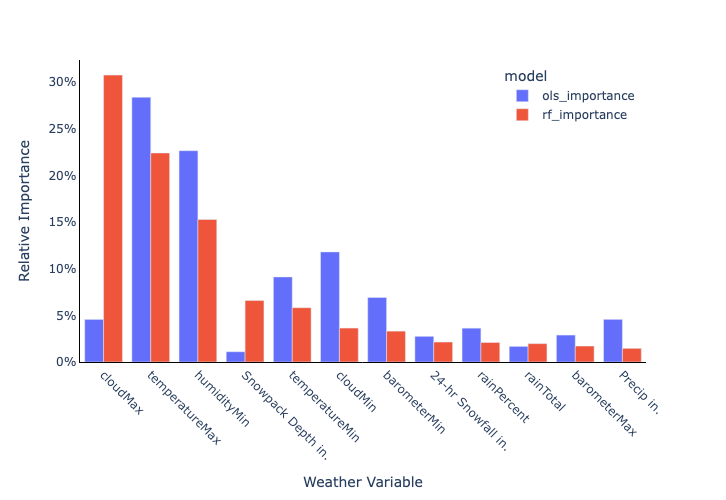

In [149]:
ols_vs_rf_viz = px.bar(
    ols_vs_rf_melt,
    x='feature',
    y='rel_importance',
    color='model',
    barmode='group',
    height=500,
    title='',
    labels={
        'feature': 'Weather Variable',
        'rel_importance': 'Relative Importance'
    }
).update_xaxes(
    showline=True,
    linewidth=1,
    linecolor='black',
    tickangle=45 
).update_yaxes(
    showline=True,
    linewidth=1,
    linecolor='black',
    tickformat='.0%'
).update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="right",
        x=0.99
    )
)

ols_vs_rf_viz.show()